In [1]:
import numpy as onp
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
n = 100  # Foreground sample size
m = 100  # Background sample size
p = 2    # Number of features
d = 1    # Latent dimension

zx = onp.random.normal(size=(n, d))    # Foreground shared latent variables
zy = onp.random.normal(size=(m, d))    # Background shared latent variables
t = onp.random.normal(size=(n, d))     # Foreground-specific latent variables
# W = onp.random.normal(size=(d, p))     # Foreground-specific loadings matrix
# S = onp.random.normal(size=(d, p))     # Shared loadings matrix
# beta = onp.random.normal(size=(d, 1))  # Coefficient vector

W = [[-10.123,5.543]]     # Foreground-specific loadings matrix
S = [[1.908,2.67]]    # Shared loadings matrix
beta = [[1.103]]   # Coefficient vector
sigma = 2e-2                           # Data matrix noise variance
tau = 5e-1                             # Response noise variance

print('==S==')
print(S)
print('==W==')
print(W)
print('==beta==')
print(beta)

# Foreground data
X = zx @ S + t @ W + onp.random.normal(scale=sigma, size=(n, 2))
print(type(X))
print(X.shape)

# Background data
Y = zy @ S + onp.random.normal(scale=sigma, size=(m, 2))
print(type(Y))
print(Y.shape)

# Response
R = t @ beta + onp.random.normal(scale=tau, size=(n, 1))
print(type(R))
print(R)

==S==
[[1.908, 2.67]]
==W==
[[-10.123, 5.543]]
==beta==
[[1.103]]
<class 'numpy.ndarray'>
(100, 2)
<class 'numpy.ndarray'>
(100, 2)
<class 'numpy.ndarray'>
[[-0.86147715]
 [-0.46381469]
 [-1.33120421]
 [ 2.69110827]
 [-0.71403993]
 [ 0.05297144]
 [ 1.48614438]
 [-0.17204212]
 [ 0.62432955]
 [ 0.43780965]
 [-2.24953067]
 [-0.36467836]
 [ 0.74980777]
 [-1.8919084 ]
 [-0.55253979]
 [-0.77597351]
 [ 1.32170401]
 [-0.58099968]
 [ 0.35796463]
 [-0.1416944 ]
 [ 0.46630224]
 [-0.71335946]
 [-0.35416102]
 [-2.87441096]
 [ 2.31405105]
 [ 0.0222044 ]
 [-1.3704288 ]
 [-0.08919018]
 [-1.04911906]
 [ 0.42989205]
 [-0.65654215]
 [-1.14930798]
 [-2.90393131]
 [ 0.12803823]
 [ 0.95305393]
 [-1.63739655]
 [-0.66792626]
 [ 0.2697605 ]
 [-2.1204192 ]
 [-0.96829633]
 [ 0.91573763]
 [ 0.16005176]
 [ 0.58150346]
 [ 0.46976458]
 [ 0.287378  ]
 [-0.83346023]
 [ 0.2659767 ]
 [ 2.23409087]
 [ 0.48419314]
 [-3.59642006]
 [-1.78636695]
 [-0.62323489]
 [ 1.4134145 ]
 [-0.87422981]
 [-2.0460688 ]
 [ 0.10673476]
 [ 0

In [3]:
import sys

sys.path.append("../contrastive-regression/models")
from linear_cr import LinearCR
# Instantiate model
model = LinearCR()

# Fit model
model.fit(X, Y, R, d,learning_rate=1e-3)

# Make predictions on training data
preds = model.predict(X)

Step: 0               Log marginal lik.: -9692.78
Step: 200             Log marginal lik.: -6617.11
Step: 400             Log marginal lik.: -4687.61
Step: 600             Log marginal lik.: -3690.32
Step: 800             Log marginal lik.: -3094.97
Step: 1000            Log marginal lik.: -2694.65
Step: 1200            Log marginal lik.: -2403.3
Step: 1400            Log marginal lik.: -2179.57
Step: 1600            Log marginal lik.: -2001.09
Step: 1800            Log marginal lik.: -1854.66
Step: 2000            Log marginal lik.: -1731.94
Step: 2200            Log marginal lik.: -1627.39
Step: 2400            Log marginal lik.: -1537.19
Step: 2600            Log marginal lik.: -1458.57
Step: 2800            Log marginal lik.: -1389.52
Step: 3000            Log marginal lik.: -1328.5
Step: 3200            Log marginal lik.: -1274.32
Step: 3400            Log marginal lik.: -1226.06
Step: 3600            Log marginal lik.: -1182.96
Step: 3800            Log marginal lik.: -1144.39
St

In [4]:
print('==S==')
print(model.S)
print('==W==')
print(model.W)
print('==beta==')
print(model.beta)
print('==sigma_sq==')
print(model.sigma_sq)
print('==tau_sq==')
print(model.tau_sq)
print('==preds==')
print(preds)

==S==
[[-1.9104158 -2.6693547]]
==W==
[[-10.748738    5.9844537]]
==beta==
[[1.1767126]]
==sigma_sq==
[0.00091885]
==tau_sq==
[0.25118464]
==preds==
[-3.57213914e-01  4.06551778e-01 -1.15077078e+00  2.39529824e+00
 -4.05275017e-01 -3.41140836e-01  1.47447264e+00 -5.99184155e-01
  1.26867235e+00  5.16239442e-02 -1.55469787e+00 -5.32833748e-02
  8.59690189e-01 -1.67815042e+00 -1.02079704e-01 -9.13576245e-01
  2.04387021e+00 -1.57493308e-01 -3.47357392e-01 -1.13310492e+00
 -1.10716172e-01 -1.51280725e+00  5.83287835e-01 -3.23750806e+00
  1.83497059e+00  9.92024362e-01 -1.38977718e+00  4.62609529e-01
 -5.25450647e-01  1.44614470e+00 -9.22540724e-01 -1.30688930e+00
 -2.40449882e+00  1.36467919e-01  1.66091964e-01 -1.28784704e+00
  8.30216557e-02  2.62225926e-01 -9.89396095e-01 -6.70927644e-01
  1.00141659e-01 -4.27470803e-01 -3.85127328e-02  7.93579400e-01
  3.97512406e-01 -1.74836591e-01  1.11748767e+00  2.00162816e+00
  6.06714427e-01 -3.86424041e+00 -1.21748626e+00 -1.53938666e-01
  1.25

In [5]:
_, _, r2_contrastivereg, _, _ = linregress(R.squeeze(), preds)
print(r2_contrastivereg)

0.9249483714223781


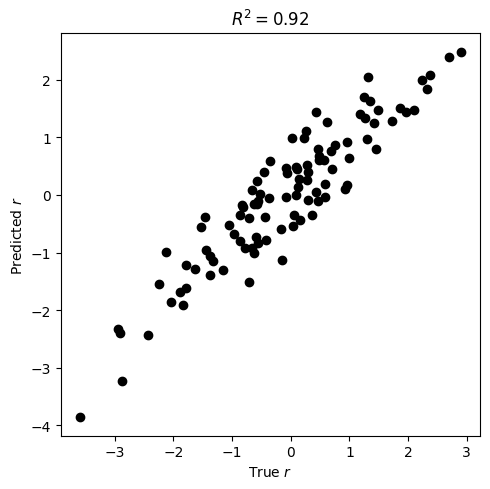

In [6]:
plt.figure(figsize=(5, 5))
plt.subplot()
plt.scatter(R, preds, c="black")
plt.xlabel(r"True $r$")
plt.ylabel(r"Predicted $r$")
plt.title(r"$R^2 = " + str(round(r2_contrastivereg, 2)) + "$")

plt.tight_layout()
plt.show()

In [7]:
# update some code in BZ
import sys

sys.path.append("../contrastive-regression/models")
from linear_cr_bz import LinearCRBZ
# Instantiate model
newmodel = LinearCRBZ()

# Fit model
newmodel.fit(X, Y, R, d)

# Make predictions on training data
newpreds = newmodel.predict(X)

Step: 0               Log marginal lik.: -10099.32
Step: 200             Log marginal lik.: -1802.91
Step: 400             Log marginal lik.: -1276.92
Step: 600             Log marginal lik.: -1083.35
Step: 800             Log marginal lik.: -988.25
Step: 1000            Log marginal lik.: -935.43
Step: 1200            Log marginal lik.: -903.54
Step: 1400            Log marginal lik.: -882.72
Step: 1600            Log marginal lik.: -867.92
Step: 1800            Log marginal lik.: -856.38
Step: 2000            Log marginal lik.: -846.59
Step: 2200            Log marginal lik.: -837.75
Step: 2400            Log marginal lik.: -829.46
Step: 2600            Log marginal lik.: -821.58
Step: 2800            Log marginal lik.: -814.08
Step: 3000            Log marginal lik.: -806.97
Step: 3200            Log marginal lik.: -800.23
Step: 3400            Log marginal lik.: -793.59
Step: 3600            Log marginal lik.: -784.58
Step: 3800            Log marginal lik.: -771.0
Step: 4000      

Step: 35800           Log marginal lik.: -287.85
Step: 36000           Log marginal lik.: -284.06
Step: 36200           Log marginal lik.: -284.17
Step: 36400           Log marginal lik.: -289.32
Step: 36600           Log marginal lik.: -286.2
Step: 36800           Log marginal lik.: -283.46
Step: 37000           Log marginal lik.: -287.38
Step: 37200           Log marginal lik.: -286.47
Step: 37400           Log marginal lik.: -286.67
Step: 37600           Log marginal lik.: -284.65
Step: 37800           Log marginal lik.: -286.01
Step: 38000           Log marginal lik.: -286.04
Step: 38200           Log marginal lik.: -284.9
Step: 38400           Log marginal lik.: -283.92
Step: 38600           Log marginal lik.: -285.79
Step: 38800           Log marginal lik.: -286.77
Step: 39000           Log marginal lik.: -286.47
Step: 39200           Log marginal lik.: -288.87
Step: 39400           Log marginal lik.: -286.3
Step: 39600           Log marginal lik.: -286.88
Step: 39800           L

In [8]:
print('==S==')
print(newmodel.S)
print('==W==')
print(newmodel.W)
print('==beta==')
print(newmodel.beta)
print('==self.sigma_sq==')
print(newmodel.sigma_sq)
print('==tau_sq==')
print(newmodel.tau_sq)
print('==preds==')
print(newpreds)

==S==
[[1.9103957 2.66945  ]]
==W==
[[-11.023084    6.1014524]]
==beta==
[[1.205018]]
==self.sigma_sq==
[0.0004452]
==tau_sq==
[0.25118798]
==preds==
[-3.5729420e-01  4.0664113e-01 -1.1510366e+00  2.3958445e+00
 -4.0536872e-01 -3.4121552e-01  1.4748139e+00 -5.9931141e-01
  1.2689700e+00  5.1640321e-02 -1.5550566e+00 -5.3287618e-02
  8.5988653e-01 -1.6785336e+00 -1.0210906e-01 -9.1378623e-01
  2.0443435e+00 -1.5752393e-01 -3.4744078e-01 -1.1333638e+00
 -1.1074260e-01 -1.5131582e+00  5.8341795e-01 -3.2382565e+00
  1.8354020e+00  9.9224794e-01 -1.3900906e+00  4.6270913e-01
 -5.2556789e-01  1.4464749e+00 -9.2276317e-01 -1.3071934e+00
 -2.4050493e+00  1.3649897e-01  1.6613467e-01 -1.2881432e+00
  8.3052747e-02  2.6228398e-01 -9.8961484e-01 -6.7108572e-01
  1.0016824e-01 -4.2757070e-01 -3.8527973e-02  7.9376483e-01
  3.9760372e-01 -1.7487697e-01  1.1177468e+00  2.0020909e+00
  6.0684860e-01 -3.8651342e+00 -1.2177600e+00 -1.5396380e-01
  1.2523421e+00 -8.0326146e-01 -1.8600693e+00  4.4500884e

In [12]:
# difference
print(abs(newmodel.S) - abs(model.S))
print(abs(newmodel.W) - abs(model.W))
print(abs(newmodel.beta) - abs(model.beta))
print(newmodel.sigma_sq - model.sigma_sq)
print(newmodel.tau_sq - model.tau_sq)
print(max(preds - newpreds))

[[-2.002716e-05  9.536743e-05]]
[[0.2743454  0.11699867]]
[[0.02830541]]
[-0.00047365]
[3.33786e-06]
0.00089383125


In [10]:
_, _, new_r2_contrastivereg, _, _ = linregress(R.squeeze(), newpreds)
print(new_r2_contrastivereg)

0.9249483690514543


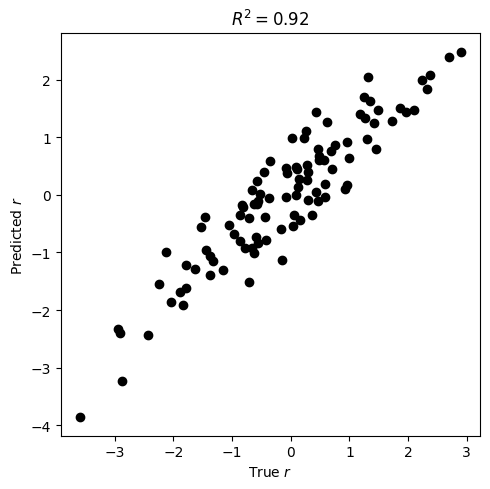

In [11]:
plt.figure(figsize=(5, 5))
plt.subplot()
plt.scatter(R, newpreds, c="black")
plt.xlabel(r"True $r$")
plt.ylabel(r"Predicted $r$")
plt.title(r"$R^2 = " + str(round(new_r2_contrastivereg, 2)) + "$")

plt.tight_layout()
plt.show()